In [2]:
!nvidia-smi

Mon Jul 13 23:56:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.74                 KMD Version: 610.74        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   58C    P0             32W /   80W |    1668MiB /   6144MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

In [4]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3060 Laptop GPU'

In [5]:
torch.cuda.is_available()

True

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

Usando: cuda


In [4]:
from pathlib import Path

# Definimos los paths para los directorios de datos

DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

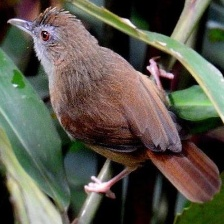

In [13]:
from PIL import Image

# Miramos una imagen de ejemplo de las imagenes de cada path
sample_species_train = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])[0]
sample_species_valid = sorted([d.name for d in VALID_DIR.iterdir() if d.is_dir()])[0]
sample_species_test = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])[0]

sample_img_path_train = next((TRAIN_DIR / sample_species_train).glob("*.jpg"))
sample_img_path_valid = next((VALID_DIR / sample_species_valid).glob("*.jpg"))
sample_img_path_test = next((TEST_DIR / sample_species_test).glob("*.jpg"))

img_train = Image.open(sample_img_path_train)
img_valid = Image.open(sample_img_path_valid)
img_test = Image.open(sample_img_path_test)

img_train
img_valid   
img_test
